In [1]:
import sys
sys.path.append("..")
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data import SECTORS

f = sorted(glob.glob("../data/snapshots/fundamentals_*.csv"))[-1]
print("loading", f)
df = pd.read_csv(f)
print(df.shape)

loading ../data/snapshots/fundamentals_2026-10-04.csv
(539, 11)


/Users/chaitanya/Desktop/sector-thesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
print(df["error"].notna().sum(), "rows with errors")
print(df.loc[df["error"].notna(), ["etf", "Ticker", "Weight"]])
print(df[["forward_pe", "trailing_pe", "rev90_0y", "rev90_+1y"]].notna().mean().round(2))
print(df.groupby("etf")["Weight"].sum().round(1))

1 rows with errors
     etf Ticker    Weight
142  XLF      L  0.230605
forward_pe     0.94
trailing_pe    0.89
rev90_0y       0.92
rev90_+1y      0.92
dtype: float64
etf
XLB      99.9
XLC     100.0
XLE     100.0
XLF     100.0
XLI     100.0
XLK     100.0
XLP      99.8
XLRE     99.7
XLU      99.9
XLV      99.9
XLY     100.0
Name: Weight, dtype: float64


In [3]:
bad = df["Ticker"].str.contains(r"Z\d$", regex=True) | (df["Ticker"] == "-") | df["error"].notna()
print("dropping:", df.loc[bad, "Ticker"].tolist())
df = df[~bad].copy()

# weights rescaled to sum to 1 within each ETF
df["w"] = df["Weight"] / df.groupby("etf")["Weight"].transform("sum")

dropping: ['-', 'IXTZ6', '-', 'L', '-', '-', '-', 'IXAZ6', '-', '-', 'IXPZ6', '-', '-', 'IXCZ6', '-', '-', 'IXYZ6', '-', '-', '-', 'IXRZ6', '-', '-', 'IXIZ6', '-', 'IXDZ6', '-', '-', '-', 'IXSZ6', '-', '-', 'XARZ6', '-', '-', 'XASZ6']


In [4]:
def wavg(g, col, lo=None, hi=None):
    s = g[col]
    if lo is not None:
        s = s.clip(lo, hi)
    m = s.notna()
    return (s[m] * g.loc[m, "w"]).sum() / g.loc[m, "w"].sum() if m.any() else np.nan

# earnings yield (1/PE) only for profitable names
df["fwd_ey"] = np.where(df["forward_pe"] > 0, 1 / df["forward_pe"], np.nan)
df["trail_ey"] = np.where(df["trailing_pe"] > 0, 1 / df["trailing_pe"], np.nan)

rows = {}
for etf, g in df.groupby("etf"):
    rows[etf] = {
        "fwd_ey": wavg(g, "fwd_ey"),
        "trail_ey": wavg(g, "trail_ey"),
        "rev90_0y": wavg(g, "rev90_0y", -0.5, 0.5),
        "rev90_+1y": wavg(g, "rev90_+1y", -0.5, 0.5),
        "coverage_fwd": g.loc[g["fwd_ey"].notna(), "w"].sum(),
    }

val = pd.DataFrame(rows).T
val["fwd_pe_implied"] = 1 / val["fwd_ey"]
val["sector"] = pd.Series(SECTORS)
val.round(3)

,fwd_ey,trail_ey,rev90_0y,rev90_+1y,coverage_fwd,fwd_pe_implied,sector
XLB,0.068,0.044,-0.098,-0.008,1.000,14.768,Materials
XLC,0.072,0.061,0.062,-0.021,1.000,13.924,Communication Services
XLE,0.077,0.056,0.139,0.116,1.000,13.021,Energy
XLF,0.072,0.066,0.033,0.022,1.000,13.905,Financials
XLI,0.046,0.036,0.020,0.033,1.000,21.960,Industrials
XLK,0.052,0.029,0.069,0.117,1.000,19.111,Technology
XLP,0.056,0.042,0.019,0.004,1.000,17.961,Consumer Staples
XLRE,0.032,0.032,-0.002,-0.005,0.991,31.135,Real Estate
XLU,0.066,0.055,0.002,-0.005,1.000,15.254,Utilities
XLV,0.059,0.033,0.023,0.015,0.988,16.965,Health Care


In [5]:
def z(s):
    return (s - s.mean()) / s.std()

scores = pd.read_csv("../data/processed/scorecard_baseline.csv", index_col=0)
scores["cheapness"] = z(val["fwd_ey"])
scores["revisions"] = (z(val["rev90_0y"]) + z(val["rev90_+1y"])) / 2

scores["composite_v2"] = scores[["momentum", "low_risk", "macro_fit", "revisions"]].mean(axis=1)
scores = scores.sort_values("composite_v2", ascending=False)
scores.to_csv("../data/processed/scorecard_v2.csv")
scores.round(2)

,momentum,low_risk,macro_fit,composite,sector,cheapness,revisions,composite_v2
XLE,1.53,-0.98,2.04,0.86,Energy,1.33,1.83,1.11
XLV,0.51,0.81,0.53,0.62,Health Care,0.01,-0.15,0.42
XLP,-0.28,1.15,0.95,0.61,Consumer Staples,-0.23,-0.31,0.38
XLK,1.61,-1.79,-0.36,-0.18,Technology,-0.48,1.26,0.18
XLC,-0.43,0.51,0.10,0.06,Communication Services,0.96,-0.20,-0.01
XLI,-0.31,0.23,-0.18,-0.09,Industrials,-0.98,0.00,-0.07
XLF,-0.16,0.00,-0.42,-0.19,Financials,0.97,-0.01,-0.14
XLU,-1.11,-0.33,0.38,-0.35,Utilities,0.50,-0.54,-0.40
XLB,-0.19,0.11,-0.20,-0.09,Materials,0.66,-1.40,-0.42
XLRE,-0.51,0.95,-1.65,-0.40,Real Estate,-1.97,-0.57,-0.45


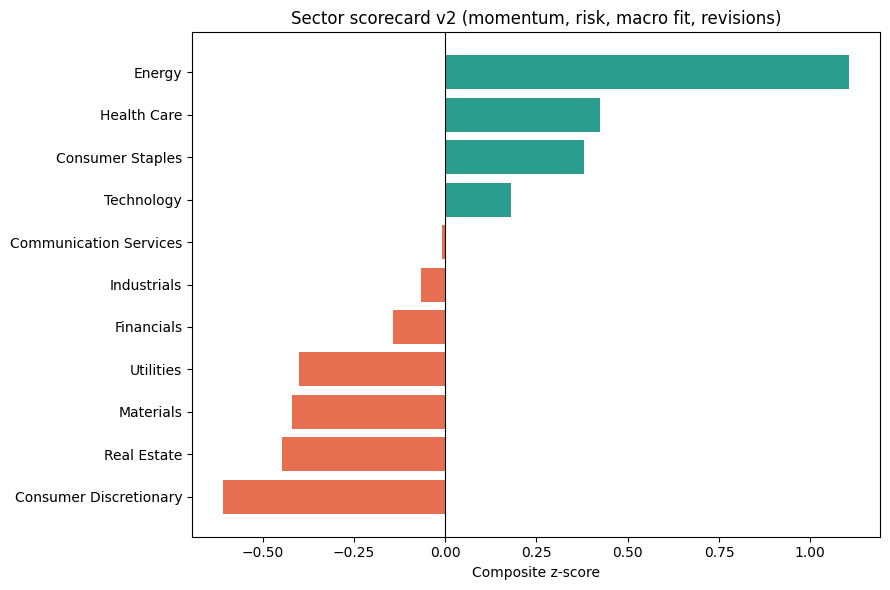

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
s = scores.sort_values("composite_v2")
colors = ["#2a9d8f" if v > 0 else "#e76f51" for v in s["composite_v2"]]
ax.barh(s["sector"], s["composite_v2"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Sector scorecard v2 (momentum, risk, macro fit, revisions)")
ax.set_xlabel("Composite z-score")
plt.tight_layout()
plt.savefig("../figures/scorecard_v2.png", dpi=200)
plt.show()